In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [26]:
import glob

# 1. Base Original Image Path
img_pattern = '/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/B.%20Disease%20Grading/B. Disease Grading/1. Original Images/a. Training Set/*.jpg'

# 2. Dedicated Target Lesion Mask Path (Targeting Hard Exudates 'EX' as our first fix)
msk_pattern = '/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/A.%20Segmentation/A. Segmentation/2. Groundtruths/a. Training Set/3. Hard Exudates/*.tif'

img_paths = sorted(glob.glob(img_pattern))
msk_paths = sorted(glob.glob(msk_pattern))

print(f"Images found: {len(img_paths)}")
print(f"Masks found: {len(msk_paths)}")

Images found: 413
Masks found: 0


In [27]:
import os

# Let's list the top-level directories in your input folder
base_path = '/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/'
if os.path.exists(base_path):
    print("Found folders inside dataset:")
    print(os.listdir(base_path))
else:
    print("Dataset path not found. Printing all available items in /kaggle/input/:")
    print(os.listdir('/kaggle/input/'))

Found folders inside dataset:
['A.%20Segmentation', 'B.%20Disease%20Grading', 'C.%20Localization']


In [32]:


# Update paths to match the exact literal folder names
img_pattern = '/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/B.%20Disease%20Grading/B.%20Disease%20Grading/1.%20Original%20Images/a.%20Training%20Set/*.jpg'
msk_pattern = '/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/A.%20Segmentation/A.%20Segmentation/2.%20Groundtruths/a.%20Training%20Set/3.%20Hard%20Exudates/*.tif'

img_paths = sorted(glob.glob(img_pattern))
msk_paths = sorted(glob.glob(msk_pattern))

print(f"Images found: {len(img_paths)}")
print(f"Masks found: {len(msk_paths)}")

Images found: 0
Masks found: 0


In [30]:
import os

# Let's inspect what is inside the Segmentation folder
seg_path = '/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/A.%20Segmentation'

if os.path.exists(seg_path):
    print("Contents of A.%20Segmentation:")
    print(os.listdir(seg_path))
else:
    print("Path does not exist.")

Contents of A.%20Segmentation:
['A. Segmentation']


In [34]:
import os


# Base path using what we just discovered
base_path = '/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset'

# Let's find all JPGs and TIFs anywhere inside this dataset automatically
all_jpgs = sorted(glob.glob(os.path.join(base_path, '**/*.jpg'), recursive=True))
all_tifs = sorted(glob.glob(os.path.join(base_path, '**/*.tif'), recursive=True))

print(f"Total JPG images found anywhere in dataset: {len(all_jpgs)}")
print(f"Total TIF masks found anywhere in dataset: {len(all_tifs)}")

if len(all_jpgs) > 0:
    print(f"\nExample Image Path:\n{all_jpgs[0]}")
if len(all_tifs) > 0:
    print(f"\nExample Mask Path:\n{all_tifs[0]}")

Total JPG images found anywhere in dataset: 1113
Total TIF masks found anywhere in dataset: 363

Example Image Path:
/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/A.%20Segmentation/A. Segmentation/1. Original Images/a. Training Set/IDRiD_01.jpg

Example Mask Path:
/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/A.%20Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/1. Microaneurysms/IDRiD_01_MA.tif


**Preprocessing starts from here,the above work was done to ensure the correct path of mask**

**We load the first matching image and microaneurysm mask from the dataset using the verified paths.**

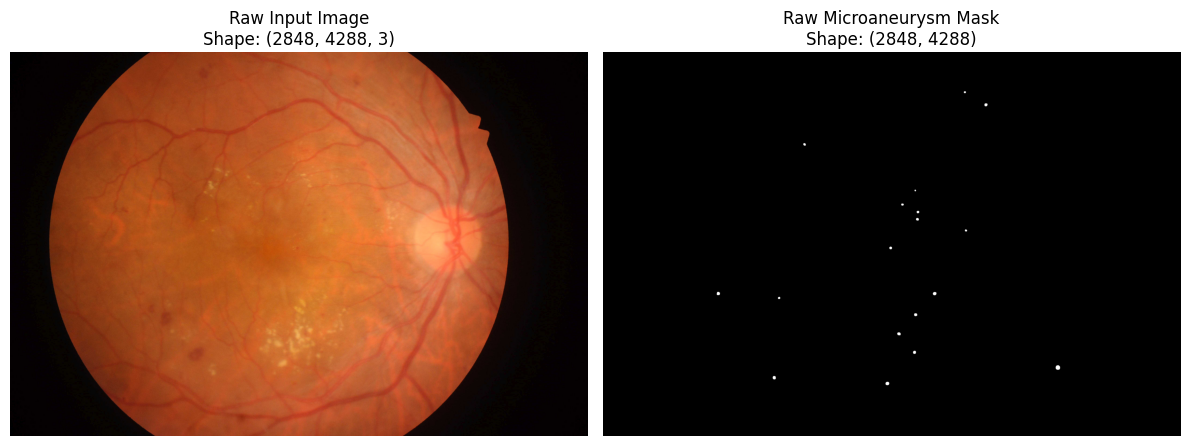

In [35]:
import cv2
import matplotlib.pyplot as plt

# Using the exact working paths found by the discovery script
sample_img_path = '/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/A.%20Segmentation/A. Segmentation/1. Original Images/a. Training Set/IDRiD_01.jpg'
sample_msk_path = '/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/A.%20Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/1. Microaneurysms/IDRiD_01_MA.tif'

# Load files
raw_img = cv2.imread(sample_img_path)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB) 
raw_msk = cv2.imread(sample_msk_path, cv2.IMREAD_GRAYSCALE) 
# Visual Output Check
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(raw_img)
ax[0].set_title(f"Raw Input Image\nShape: {raw_img.shape}")
ax[0].axis('off')

ax[1].imshow(raw_msk, cmap='gray')
ax[1].set_title(f"Raw Microaneurysm Mask\nShape: {raw_msk.shape}")
ax[1].axis('off')

plt.tight_layout()
plt.show()

**We look at the brightness of the raw image to locate where the black background ends and the eye structure begins. Then, we apply that identical bounding box to both the image and the mask arrays.**

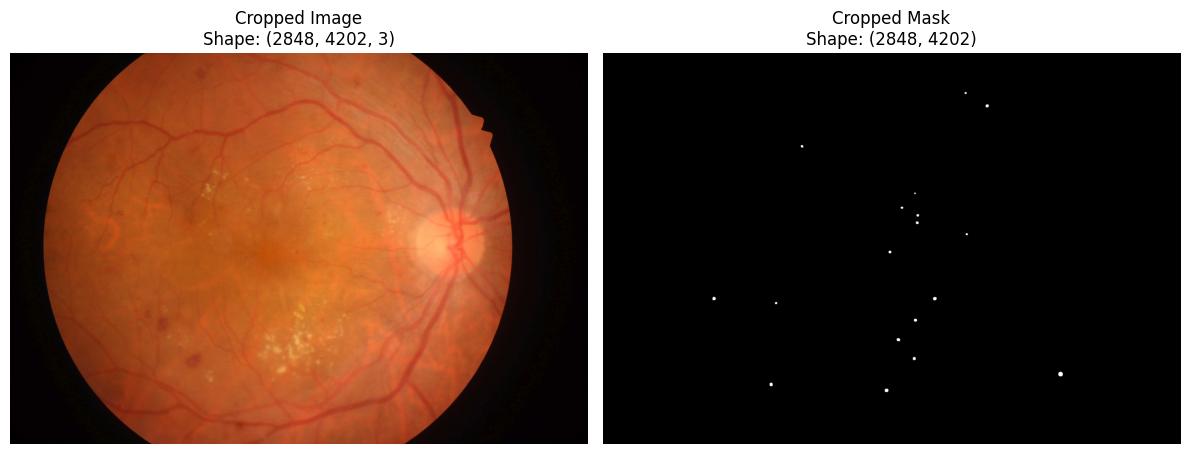

In [36]:
import numpy as np

def crop_image_and_mask(image, mask, tol=7):
    """
    Finds the bounding box of the fundus circle on the image 
    and crops both the image and mask to the exact same boundaries.
    """
   
    gray_img = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    
    mask_indices = gray_img > tol
    
    
    row_indices = np.ix_(mask_indices.any(1))[0]
    col_indices = np.ix_(mask_indices.any(0))[0]
    
    # If the image is completely black, return originals to avoid errors
    if len(row_indices) == 0 or len(col_indices) == 0:
        return image, mask
        
    
    cropped_img = image[row_indices[0]:row_indices[-1]+1, col_indices[0]:col_indices[-1]+1]
    cropped_msk = mask[row_indices[0]:row_indices[-1]+1, col_indices[0]:col_indices[-1]+1]
    
    return cropped_img, cropped_msk

# Run the synchronized cropping function on our raw inputs
cropped_image, cropped_mask = crop_image_and_mask(raw_img, raw_msk)

# --- Visual Output Check ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(cropped_image)
ax[0].set_title(f"Cropped Image\nShape: {cropped_image.shape}")
ax[0].axis('off')

ax[1].imshow(cropped_mask, cmap='gray')
ax[1].set_title(f"Cropped Mask\nShape: {cropped_mask.shape}")
ax[1].axis('off')

plt.tight_layout()
plt.show()

**We downscale both arrays to a standardized 512x512 grid. We use bilinear interpolation for the structural detail of the image and nearest-neighbor interpolation for the mask to preserve exact label values.**

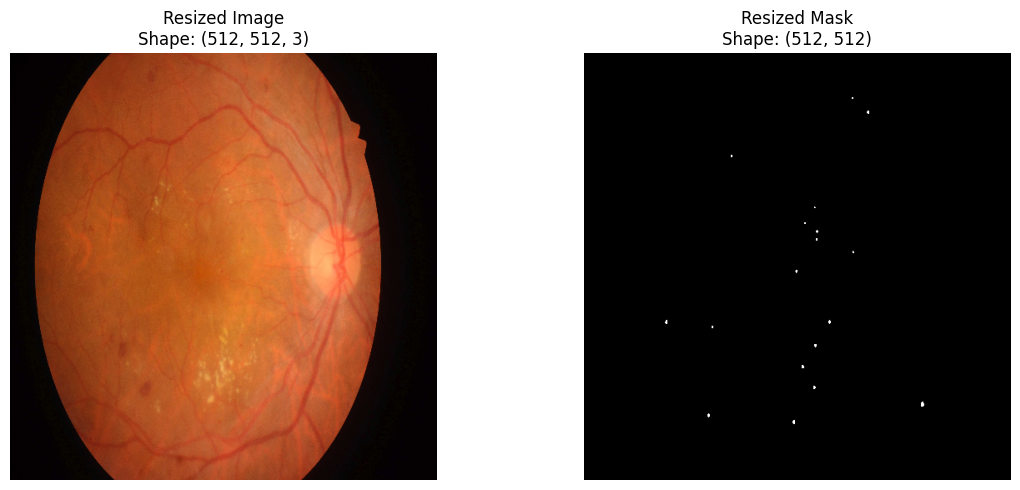

In [37]:
# Standard target size for the network
TARGET_SIZE = (512, 512)

# 1. Resize the image smoothly
resized_image = cv2.resize(cropped_image, TARGET_SIZE, interpolation=cv2.INTER_LINEAR)

# 2. Resize the mask using nearest-neighbor to avoid edge blurriness
resized_mask = cv2.resize(cropped_mask, TARGET_SIZE, interpolation=cv2.INTER_NEAREST)

# --- Visual Output Check ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(resized_image)
ax[0].set_title(f"Resized Image\nShape: {resized_image.shape}")
ax[0].axis('off')

ax[1].imshow(resized_mask, cmap='gray')
ax[1].set_title(f"Resized Mask\nShape: {resized_mask.shape}")
ax[1].axis('off')

plt.tight_layout()
plt.show()

**We isolate the green channel (index 1) from our uniformly resized RGB image to capture the highest natural structural contrast.**

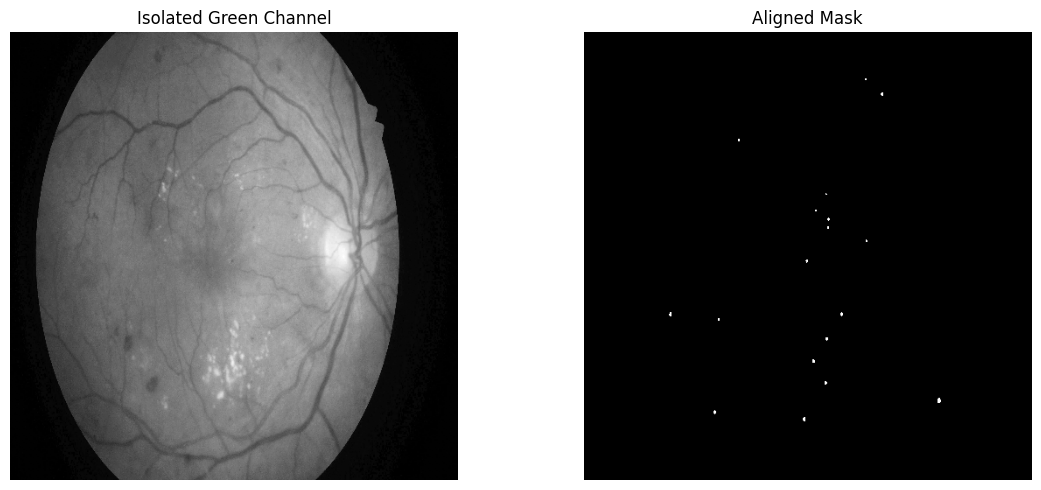

In [39]:
# Extract the Green Channel (Index 1 in RGB)
green_channel = resized_image[:, :, 1]

# --- Visual Output Check ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(green_channel, cmap='gray')
ax[0].set_title("Isolated Green Channel")
ax[0].axis('off')

ax[1].imshow(resized_mask, cmap='gray')
ax[1].set_title("Aligned Mask")
ax[1].axis('off')

plt.tight_layout()
plt.show()

**We apply Contrast-Limited Adaptive Histogram Equalization to our isolated green channel to flatten uneven illumination and maximize edge boundaries.**

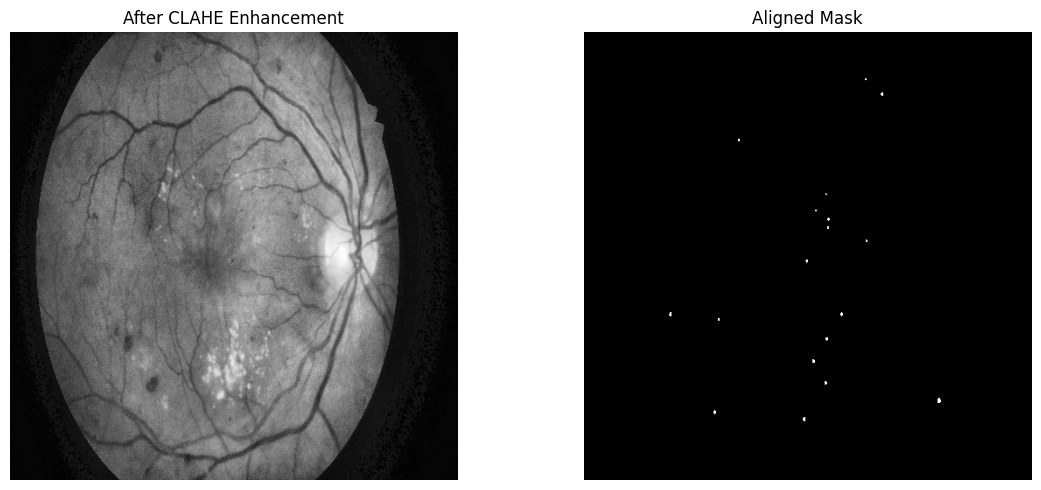

In [40]:
# 1. Configure the CLAHE operator
# clipLimit=2.0 prevents noise amplification; tileGridSize divides the image into local blocks
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# 2. Apply CLAHE to the green channel array
enhanced_image = clahe.apply(green_channel)

# --- Visual Output Check ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(enhanced_image, cmap='gray')
ax[0].set_title("After CLAHE Enhancement")
ax[0].axis('off')

ax[1].imshow(resized_mask, cmap='gray')
ax[1].set_title("Aligned Mask")
ax[1].axis('off')

plt.tight_layout()
plt.show()

**We apply a 3x3 median filter to our enhanced image to wipe away high-frequency camera noise while preserving sharp structural boundaries.**

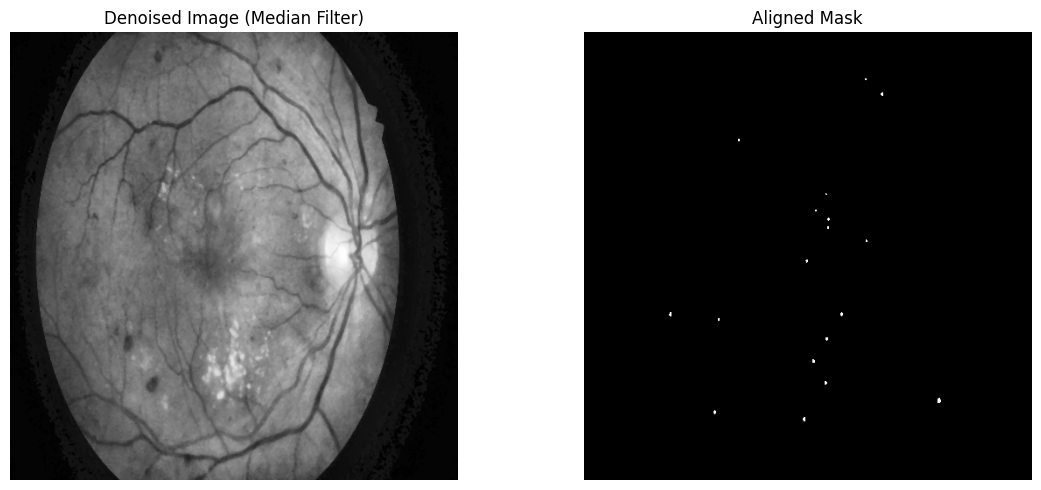

In [41]:
# Apply a median blur with a small kernel size of 3 to preserve fine structures
denoised_image = cv2.medianBlur(enhanced_image, ksize=3)

# --- Visual Output Check ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(denoised_image, cmap='gray')
ax[0].set_title("Denoised Image (Median Filter)")
ax[0].axis('off')

ax[1].imshow(resized_mask, cmap='gray')
ax[1].set_title("Aligned Mask")
ax[1].axis('off')

plt.tight_layout()
plt.show()

**We pass both our preprocessed image and mask into Albumentations simultaneously. The library applies random geometric changes to both arrays in perfect spatial alignment.**

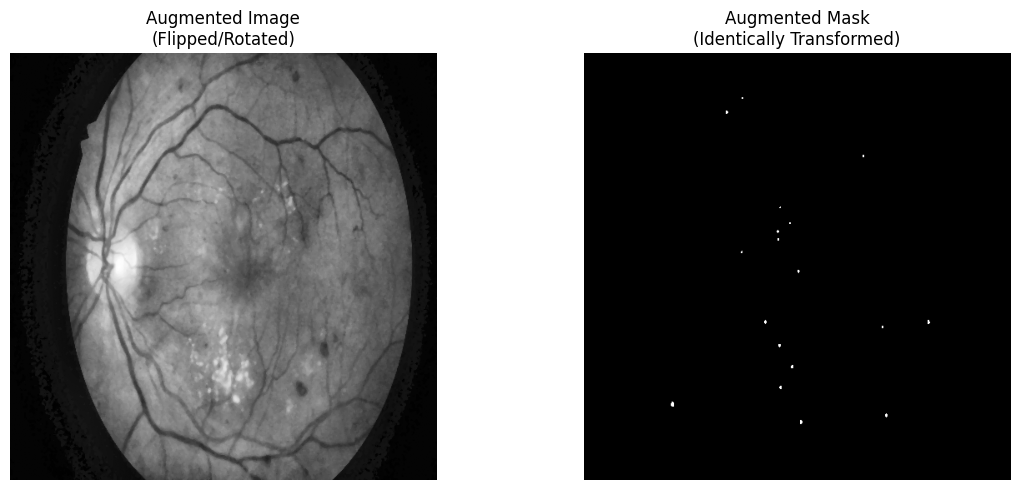

In [42]:
import albumentations as A
import numpy as np

# 1. Define the augmentation pipeline
transform_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),    # 50% chance to flip horizontally
    A.VerticalFlip(p=0.5),      # 50% chance to flip vertically
    A.RandomRotate90(p=0.5)     # 50% chance to rotate by 90 degrees
])

# 2. Albumentations expects a 3-channel layout or explicit channel mapping.
# Since our denoised image is single-channel, we duplicate it into 3 identical channels 
# so it mimics a standard image canvas for the augmentation library.
processed_canvas = np.stack([denoised_image, denoised_image, denoised_image], axis=-1)

# 3. Apply the pipeline to BOTH the image and mask simultaneously
augmented = transform_pipeline(image=processed_canvas, mask=resized_mask)

# 4. Extract the mirrored results
augmented_image = augmented['image'][:, :, 0] # Extract back a single channel for viewing
augmented_mask = augmented['mask']

# --- Visual Output Check ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(augmented_image, cmap='gray')
ax[0].set_title("Augmented Image\n(Flipped/Rotated)")
ax[0].axis('off')

ax[1].imshow(augmented_mask, cmap='gray')
ax[1].set_title("Augmented Mask\n(Identically Transformed)")
ax[1].axis('off')

plt.tight_layout()
plt.show()

**We create a clean PyTorch Dataset class that applies our step-by-step preprocessing pipeline on-the-fly to every file pair, then build DataLoaders to group them into training batches.**

In [43]:
import os
import cv2
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

# =====================================================================
# 1. PARSE VALIDATED PATHS FOR THE ENTIRE DATASET
# =====================================================================
IMG_PATTERN = '/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/A.%20Segmentation/A. Segmentation/1. Original Images/a. Training Set/*.jpg'
MSK_PATTERN = '/kaggle/input/datasets/aaryapatel98/indian-diabetic-retinopathy-image-dataset/A.%20Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/1. Microaneurysms/*.tif'

all_img_paths = sorted(glob.glob(IMG_PATTERN))
all_msk_paths = sorted(glob.glob(MSK_PATTERN))

# Safety check
assert len(all_img_paths) == len(all_msk_paths), f"Mismatch! Found {len(all_img_paths)} images but {len(all_msk_paths)} masks."

# Split paths manually: 85% for Training, 15% for Validation
split_idx = int(len(all_img_paths) * 0.85)
train_img_paths, train_msk_paths = all_img_paths[:split_idx], all_msk_paths[:split_idx]
val_img_paths, val_msk_paths = all_img_paths[split_idx:], all_msk_paths[split_idx:]


# =====================================================================
# 2. DEFINE THE MASTER PYTORCH DATASET CLASS
# =====================================================================
class IDRiDDataset(Dataset):
    def __init__(self, img_paths, msk_paths, augment=False):
        self.img_paths = img_paths
        self.msk_paths = msk_paths
        self.augment = augment
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        
        # Step 6: Define Spatial Augmentations
        self.spatial_transforms = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5)
        ])

    def __len__(self):
        return len(self.img_paths)

    def crop_image_and_mask(self, image, mask, tol=7):
        # Step 2: Image Cutting
        gray_img = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        mask_indices = gray_img > tol
        row_indices = np.ix_(mask_indices.any(1))[0]
        col_indices = np.ix_(mask_indices.any(0))[0]
        
        if len(row_indices) == 0 or len(col_indices) == 0:
            return image, mask
            
        return (image[row_indices[0]:row_indices[-1]+1, col_indices[0]:col_indices[-1]+1],
                mask[row_indices[0]:row_indices[-1]+1, col_indices[0]:col_indices[-1]+1])

    def __getitem__(self, idx):
        # Step 1: Ingestion
        raw_image = cv2.imread(self.img_paths[idx])
        raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
        raw_mask = cv2.imread(self.msk_paths[idx], cv2.IMREAD_GRAYSCALE)

        # Step 2: Image Cutting (Synchronized Bounding Box Crop)
        cropped_img, cropped_msk = self.crop_image_and_mask(raw_image, raw_mask)

        # Step 3: Resolution Handling (Uniform Resizing)
        resized_img = cv2.resize(cropped_img, (512, 512), interpolation=cv2.INTER_LINEAR)
        resized_msk = cv2.resize(cropped_msk, (512, 512), interpolation=cv2.INTER_NEAREST)

        # Step 4A & 4B: Green Channel Extraction & CLAHE
        green_channel = resized_img[:, :, 1]
        enhanced_img = self.clahe.apply(green_channel)

        # Step 5: Denoising via Median Filter
        denoised_img = cv2.medianBlur(enhanced_img, ksize=3)

        # Duplicate single channel to 3-channels so it works flawlessly with standard models
        processed_img = np.stack([denoised_img, denoised_img, denoised_img], axis=-1)

        # Step 6: Conditional Augmentation
        if self.augment:
            augmented = self.spatial_transforms(image=processed_img, mask=resized_msk)
            processed_img = augmented['image']
            resized_msk = augmented['mask']

        # Final Formatting: Convert to channel-first PyTorch tensors [C, H, W]
        img_tensor = torch.from_numpy(processed_img).permute(2, 0, 1).float() / 255.0
        
        # Binarize mask to 0.0 (background) and 1.0 (lesion), add channel dimension
        msk_tensor = (torch.from_numpy(resized_msk) > 0).float().unsqueeze(0)

        return img_tensor, msk_tensor


# =====================================================================
# 3. INITIALIZE DATALOADERS FOR MODEL TRAINING
# =====================================================================
train_dataset = IDRiDDataset(train_img_paths, train_msk_paths, augment=True)
val_dataset = IDRiDDataset(val_img_paths, val_msk_paths, augment=False)

# Batch size of 4 or 8 is optimal for 512x512 images on standard Kaggle GPUs
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)

print(f"✅ Success! Generated {len(train_loader)} training batches and {len(val_loader)} validation batches.")

✅ Success! Generated 12 training batches and 3 validation batches.
